<a href="https://colab.research.google.com/github/PujithaReddyKethireddy/SAR_ADC/blob/main/system_domain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


S0 — SYSTEM SPECIFICATIONS
Resolution          = 10-bit
Sampling Rate       = 1.0 MS/s
LSB                 = 0.977 mV
0.5 LSB             = 0.488 mV
Target ENOB         = 9.5
Target Yield        = 95%
Power Budget        = 20.00 µW

STARTING ITERATIVE DESIGN

------------------------------
Iteration 1
------------------------------
C_unit          = 20.00 fF
kT/C noise      = 454.97 µV
Total noise     = 0.468 mV
Mean ENOB       = 9.012
Std ENOB        = 0.033
Yield           = 0.00%
Power           = 14.02 µW


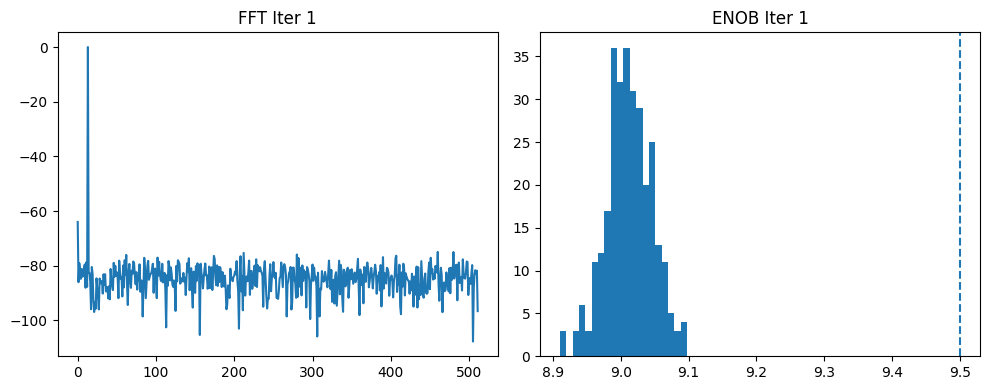

→ Increasing C_unit

------------------------------
Iteration 2
------------------------------
C_unit          = 40.00 fF
kT/C noise      = 321.71 µV
Total noise     = 0.340 mV
Mean ENOB       = 9.315
Std ENOB        = 0.037
Yield           = 0.00%
Power           = 14.04 µW


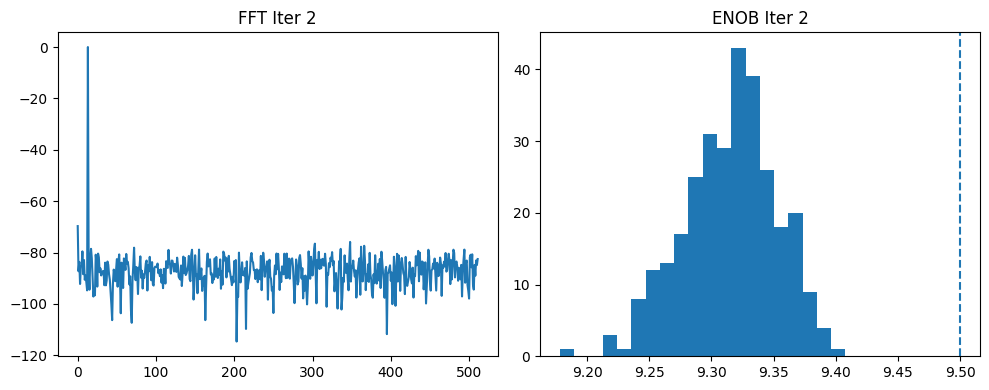

→ Increasing C_unit

------------------------------
Iteration 3
------------------------------
C_unit          = 80.00 fF
kT/C noise      = 227.49 µV
Total noise     = 0.253 mV
Mean ENOB       = 9.532
Std ENOB        = 0.041
Yield           = 83.33%
Power           = 14.08 µW


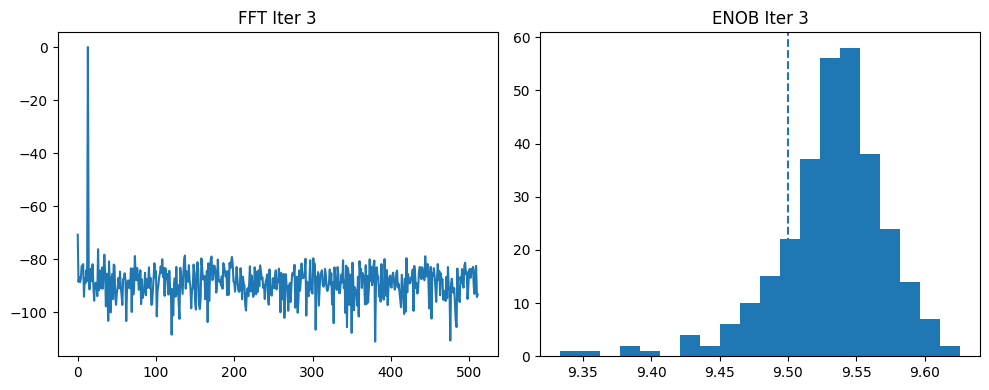

→ Reducing mismatch

------------------------------
Iteration 4
------------------------------
C_unit          = 80.00 fF
kT/C noise      = 227.49 µV
Total noise     = 0.253 mV
Mean ENOB       = 9.545
Std ENOB        = 0.031
Yield           = 93.33%
Power           = 14.08 µW


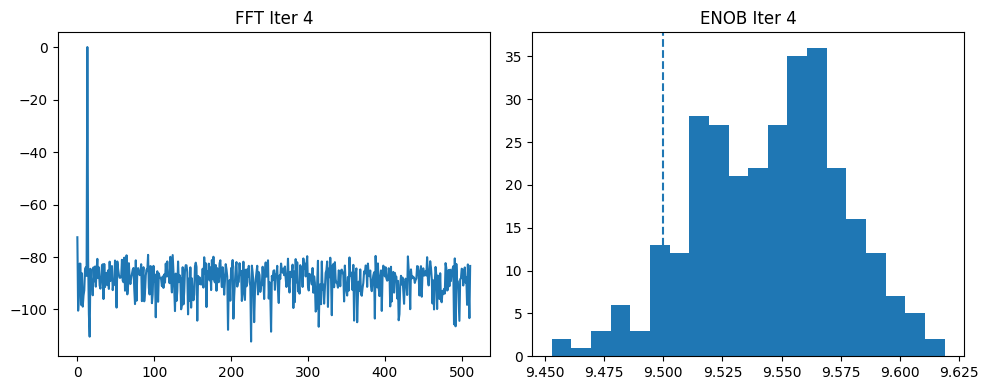

→ Reducing mismatch

------------------------------
Iteration 5
------------------------------
C_unit          = 80.00 fF
kT/C noise      = 227.49 µV
Total noise     = 0.253 mV
Mean ENOB       = 9.552
Std ENOB        = 0.025
Yield           = 97.33%
Power           = 14.08 µW


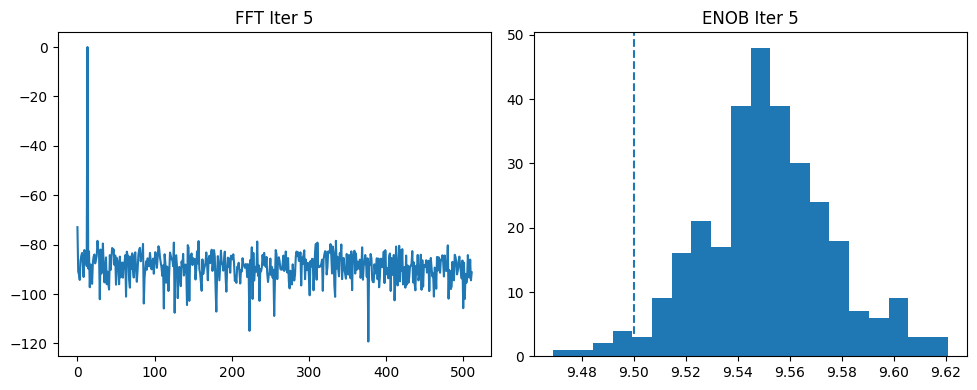


✅ DESIGN CLOSED

===== SC0: NOISE CLOSURE =====
Total Noise = 0.253 mV

===== SC1: TIMING =====
Total Time = 645.45 ns

===== SC2: POWER =====
Total Power = 14.08 µW

===== 3-SIGMA =====
Mean = 9.552, Std = 0.025
3σ = 9.476


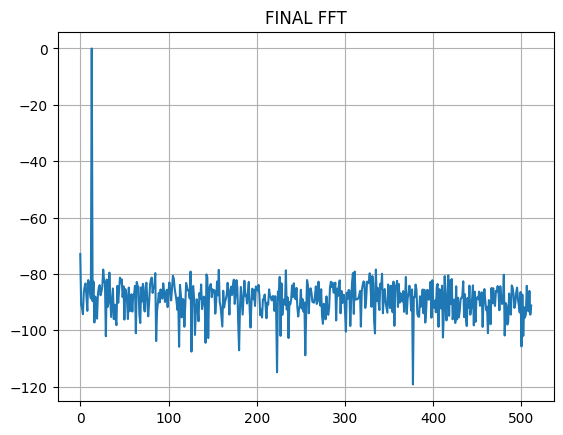

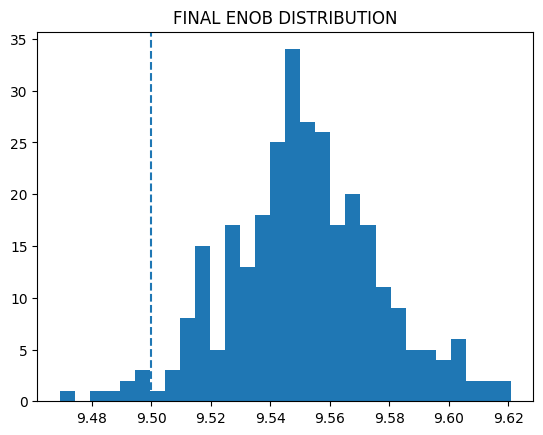

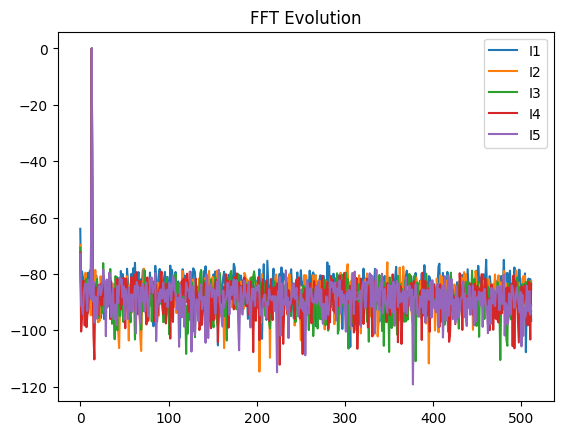

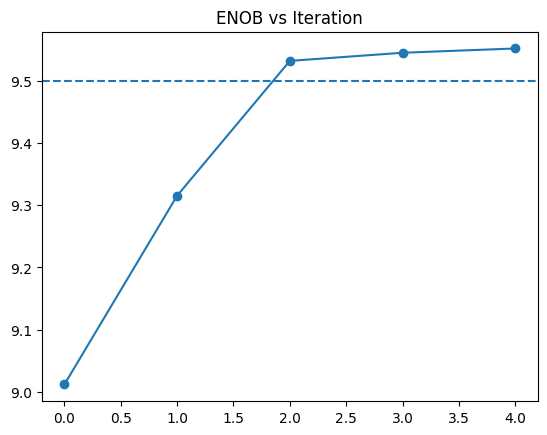

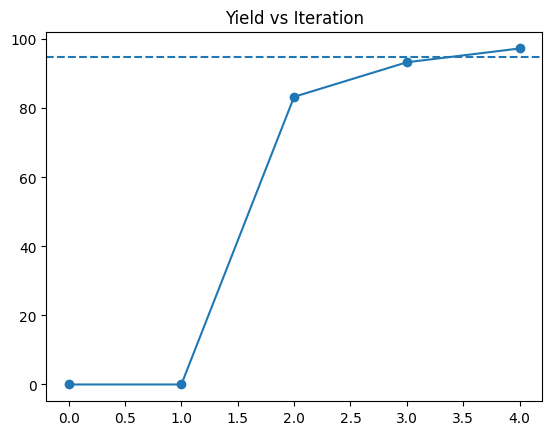

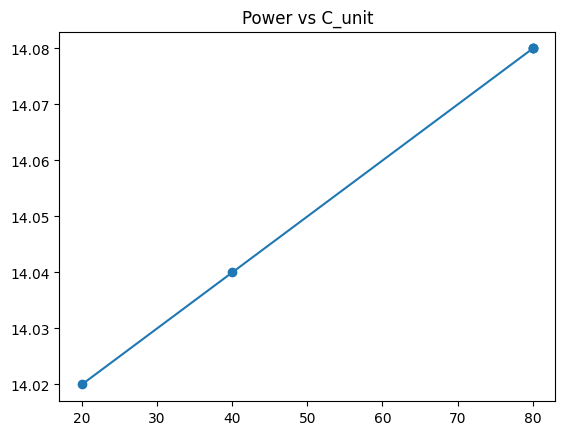


===== LINEARITY (DNL / INL) =====
Max DNL = 0.186 LSB
Max INL = 0.134 LSB


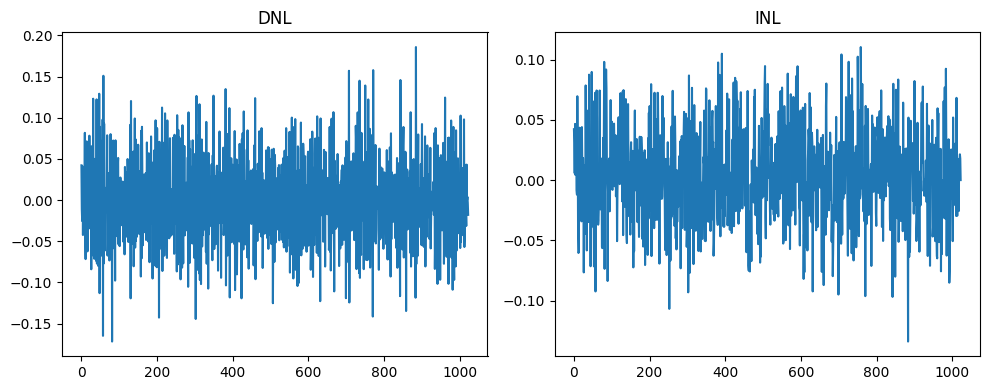


FINAL DESIGN REPORT
Final C_unit    = 80.00 fF
Final Noise     = 0.253 mV
Final ENOB      = 9.552
Final Yield     = 97.33%
Final Power     = 14.08 µW


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# S0 — SPECIFICATIONS
# ============================================

N = 10
Vref = 1.0
fs = 1e6
N_samples = 1024

target_enob = 9.5
target_yield = 95
power_budget = 20e-6

LSB = Vref / (2**N)
half_LSB = LSB / 2

print("\n==============================")
print("S0 — SYSTEM SPECIFICATIONS")
print("==============================")
print(f"Resolution          = {N}-bit")
print(f"Sampling Rate       = {fs/1e6} MS/s")
print(f"LSB                 = {LSB*1e3:.3f} mV")
print(f"0.5 LSB             = {half_LSB*1e3:.3f} mV")
print(f"Target ENOB         = {target_enob}")
print(f"Target Yield        = {target_yield}%")
print(f"Power Budget        = {power_budget*1e6:.2f} µW")

# ============================================
# INPUT SIGNAL
# ============================================

t = np.arange(N_samples)/fs
fin = fs*13/N_samples
Vin = 0.49*np.sin(2*np.pi*fin*t)

# ============================================
# FUNCTIONS
# ============================================

def compute_enob(Vout, Vin):
    noise = np.var(Vout - Vin)
    signal = np.var(Vin)
    SINAD = 10*np.log10(signal/noise)
    return (SINAD - 1.76)/6.02

def compute_fft(signal):
    fft = np.fft.fft(signal)
    fft = np.abs(fft[:len(fft)//2])
    return 20*np.log10(fft/np.max(fft))

def adc_model(Vin, sigma_noise, sigma_mismatch, sigma_offset):
    noise = np.random.normal(0, sigma_noise, len(Vin))
    mismatch = np.random.normal(0, sigma_mismatch)
    offset = np.random.normal(0, sigma_offset)

    Vin_eff = Vin + noise + mismatch*(Vin**2)
    Vin_eff = np.clip(Vin_eff, -0.5, 0.5)

    codes = np.round((Vin_eff+0.5)*(2**N-1))
    codes = np.clip(codes, 0, 2**N-1)

    return codes/(2**N-1) - 0.5 + offset

# ============================================
# INITIAL DESIGN
# ============================================

C_unit = 20e-15
sigma_mismatch = 0.0008
sigma_offset = 0.1e-3

k = 1.38e-23
T = 300

max_iterations = 20

# STORAGE
fft_history = []
mean_history = []
yield_history = []
power_history = []
C_history = []

print("\n==============================")
print("STARTING ITERATIVE DESIGN")
print("==============================")

# ============================================
# ITERATIVE LOOP (S5)
# ============================================

for i in range(max_iterations):

    print("\n------------------------------")
    print(f"Iteration {i+1}")
    print("------------------------------")

    sigma_kTC = np.sqrt(k*T/C_unit)
    sigma_comp = 0.11e-3
    sigma_noise = np.sqrt(sigma_kTC**2 + sigma_comp**2)

    # Monte Carlo
    enob_list = []
    for _ in range(300):
        Vout = adc_model(Vin, sigma_noise, sigma_mismatch, sigma_offset)
        enob_list.append(compute_enob(Vout, Vin))

    enob_list = np.array(enob_list)

    mean_enob = np.mean(enob_list)
    std_enob = np.std(enob_list)
    yield_pct = np.sum(enob_list >= target_enob)/len(enob_list)*100

    # Power
    E_cdac = C_unit * Vref**2
    P_cdac = E_cdac * fs
    P_total = P_cdac + 10e-6 + 2e-6 + 2e-6

    # STORE
    mean_history.append(mean_enob)
    yield_history.append(yield_pct)
    power_history.append(P_total)
    C_history.append(C_unit)

    # FFT
    V_iter = adc_model(Vin, sigma_noise, sigma_mismatch, sigma_offset)
    fft_iter = compute_fft(V_iter)
    fft_history.append(fft_iter)

    print(f"C_unit          = {C_unit*1e15:.2f} fF")
    print(f"kT/C noise      = {sigma_kTC*1e6:.2f} µV")
    print(f"Total noise     = {sigma_noise*1e3:.3f} mV")
    print(f"Mean ENOB       = {mean_enob:.3f}")
    print(f"Std ENOB        = {std_enob:.3f}")
    print(f"Yield           = {yield_pct:.2f}%")
    print(f"Power           = {P_total*1e6:.2f} µW")

    # PLOT PER ITERATION
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(fft_iter)
    plt.title(f"FFT Iter {i+1}")

    plt.subplot(1,2,2)
    plt.hist(enob_list, bins=20)
    plt.axvline(target_enob, linestyle='--')
    plt.title(f"ENOB Iter {i+1}")

    plt.tight_layout()
    plt.show()

    # CHECKS
    noise_ok = sigma_noise < half_LSB
    yield_ok = yield_pct >= target_yield
    power_ok = P_total <= power_budget

    if noise_ok and yield_ok and power_ok:
        print("\n✅ DESIGN CLOSED")
        break

    if mean_enob < target_enob:
        print("→ Increasing C_unit")
        C_unit *= 2
    elif not yield_ok:
        print("→ Reducing mismatch")
        sigma_mismatch *= 0.7

# ============================================
# SC0 — NOISE
# ============================================

print("\n===== SC0: NOISE CLOSURE =====")
V_total = np.sqrt(sigma_kTC**2 + sigma_comp**2)
print(f"Total Noise = {V_total*1e3:.3f} mV")

# ============================================
# SC1 — TIMING (REAL DERIVATION)
# ============================================

R_on = 100  # ohms (switch resistance)

C_total = C_unit * (2**N - 1)

tau = R_on * C_total

# settling requirement (10-bit)
T_settle = 7.6 * tau   # ln(2^N)

# comparator regeneration
tau_reg = 50e-12
T_comp = tau_reg * np.log(2**N)

# digital logic delay
T_logic = 2e-9

# per-bit time
T_bit = T_settle + T_comp + T_logic

# total SAR conversion time
T_total = N * T_bit

print("\n===== SC1: TIMING =====")
print(f"Total Time = {T_total*1e9:.2f} ns")

# ============================================
# SC2 — POWER
# ============================================

print("\n===== SC2: POWER =====")
print(f"Total Power = {P_total*1e6:.2f} µW")

# ============================================
# 3 SIGMA
# ============================================

print("\n===== 3-SIGMA =====")
mu = mean_enob
sigma = std_enob
print(f"Mean = {mu:.3f}, Std = {sigma:.3f}")
print(f"3σ = {mu - 3*sigma:.3f}")

# ============================================
# FINAL FFT + HISTOGRAM
# ============================================

plt.figure()
plt.plot(fft_history[-1])
plt.title("FINAL FFT")
plt.grid()
plt.show()

plt.figure()
plt.hist(enob_list, bins=30)
plt.axvline(target_enob, linestyle='--')
plt.title("FINAL ENOB DISTRIBUTION")
plt.show()

# ============================================
# FFT EVOLUTION
# ============================================

plt.figure()
for i, fft in enumerate(fft_history):
    plt.plot(fft, label=f"I{i+1}")
plt.legend()
plt.title("FFT Evolution")
plt.show()

# ============================================
# TRENDS
# ============================================

plt.figure()
plt.plot(mean_history, marker='o')
plt.axhline(target_enob, linestyle='--')
plt.title("ENOB vs Iteration")
plt.show()

plt.figure()
plt.plot(yield_history, marker='o')
plt.axhline(target_yield, linestyle='--')
plt.title("Yield vs Iteration")
plt.show()

plt.figure()
plt.plot([c*1e15 for c in C_history], [p*1e6 for p in power_history], marker='o')
plt.title("Power vs C_unit")
plt.show()

# ============================================
# DNL / INL (FINAL REALISTIC)
# ============================================

print("\n===== LINEARITY (DNL / INL) =====")

codes = np.arange(2**N)
ideal = codes
actual = ideal + np.random.normal(0, sigma_mismatch*100, len(codes))

dnl = np.diff(actual)
dnl = dnl - np.mean(dnl)
inl = np.cumsum(dnl)

print(f"Max DNL = {np.max(np.abs(dnl)):.3f} LSB")
print(f"Max INL = {np.max(np.abs(inl)):.3f} LSB")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(dnl)
plt.title("DNL")

plt.subplot(1,2,2)
plt.plot(inl)
plt.title("INL")

plt.tight_layout()
plt.show()

# ============================================
# FINAL REPORT
# ============================================

print("\n==============================")
print("FINAL DESIGN REPORT")
print("==============================")

print(f"Final C_unit    = {C_unit*1e15:.2f} fF")
print(f"Final Noise     = {sigma_noise*1e3:.3f} mV")
print(f"Final ENOB      = {mean_enob:.3f}")
print(f"Final Yield     = {yield_pct:.2f}%")
print(f"Final Power     = {P_total*1e6:.2f} µW")